In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')

print(df.shape)
print(df.dtypes)
df.head()

(1460, 81)
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


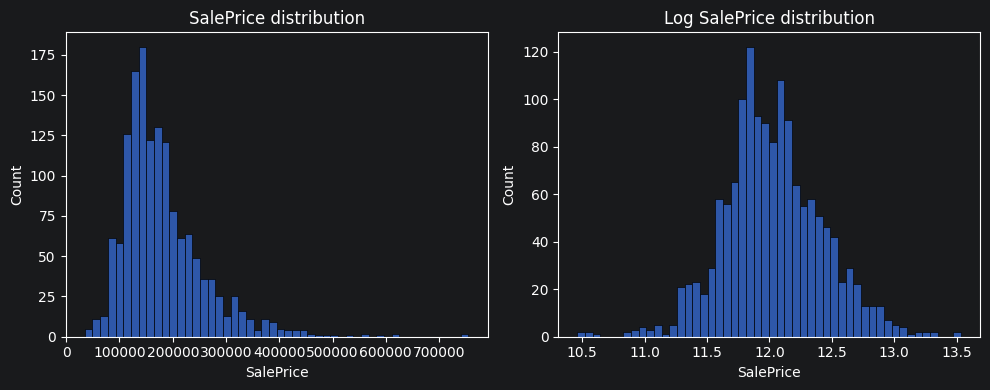

In [3]:
print(df['SalePrice'].describe())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], bins=50)
plt.title('SalePrice distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), bins=50)
plt.title('Log SalePrice distribution')

plt.tight_layout()
plt.show()

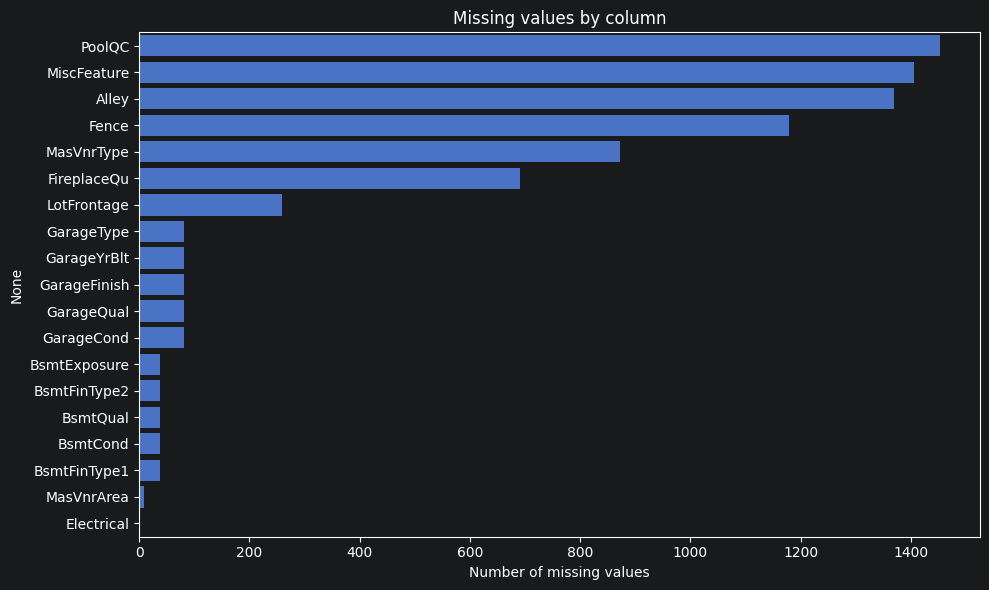

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values, y=missing.index)
plt.title('Missing values by column')
plt.xlabel('Number of missing values')
plt.tight_layout()
plt.show()

print(missing)

In [6]:
# "None" for categorical columns where NaN means the feature doesn't exist
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

# 0 for numeric columns where NaN means the feature doesn't exist
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

# LotFrontage: fill with median of the same neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical: drop the one missing row
df = df.dropna(subset=['Electrical'])

# Verify nothing is left
print(df.isnull().sum().sum())

0


In [7]:
# Total square footage (more predictive than individual floor areas)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# House age at time of sale
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Was the house remodeled?
df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# Total bathrooms
df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 +
                   df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)

# Quick check
print(df[['TotalSF', 'HouseAge', 'WasRemodeled', 'TotalBath']].head())

   TotalSF  HouseAge  WasRemodeled  TotalBath
0     2566         5             0        3.5
1     2524        31             0        2.5
2     2706         7             1        3.5
3     2473        91             1        2.0
4     3343         8             0        3.5


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Target: log transform SalePrice
y = np.log1p(df['SalePrice'])

# Drop columns we don't want as features
X = df.drop(['SalePrice', 'Id'], axis=1)

# Encode categorical (text) columns as numbers
cat_cols = X.select_dtypes(include='str').columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (1168, 79)
Test set:     (292, 79)


In [ ]:
# Catch any remaining nulls in numeric columns
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(X_train['LotFrontage'].median())
X_train['MasVnrArea'] = X_train['MasVnrArea'].fillna(0)
X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(0)

X_test['LotFrontage'] = X_test['LotFrontage'].fillna(X_train['LotFrontage'].median())
X_test['MasVnrArea'] = X_test['MasVnrArea'].fillna(0)
X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(0)

# Confirm clean
print('Remaining nulls:', X_train.isnull().sum().sum())

In [18]:
# Check what's still null
null_cols = X_train.columns[X_train.isnull().any()]
print('Still null:', null_cols.tolist())

# Fill everything remaining — numeric with median, categorical with 0
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# Confirm
print('Nulls remaining:', X_train.isnull().sum().sum())

Still null: ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
Nulls remaining: 0


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print(f'Linear Regression')
print(f'  RMSE: {lr_rmse:.4f}')
print(f'  R²:   {lr_r2:.4f}')

Linear Regression
  RMSE: 0.1551
  R²:   0.8712


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print(f'Random Forest')
print(f'  RMSE: {rf_rmse:.4f}')
print(f'  R²:   {rf_r2:.4f}')

Random Forest
  RMSE: 0.1440
  R²:   0.8889


In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                   max_depth=4, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(f'XGBoost')
print(f'  RMSE: {xgb_rmse:.4f}')
print(f'  R²:   {xgb_r2:.4f}')

XGBoost
  RMSE: 0.1403
  R²:   0.8946


            Model     RMSE       R²
Linear Regression 0.155062 0.871153
    Random Forest 0.143963 0.888939
          XGBoost 0.140250 0.894593


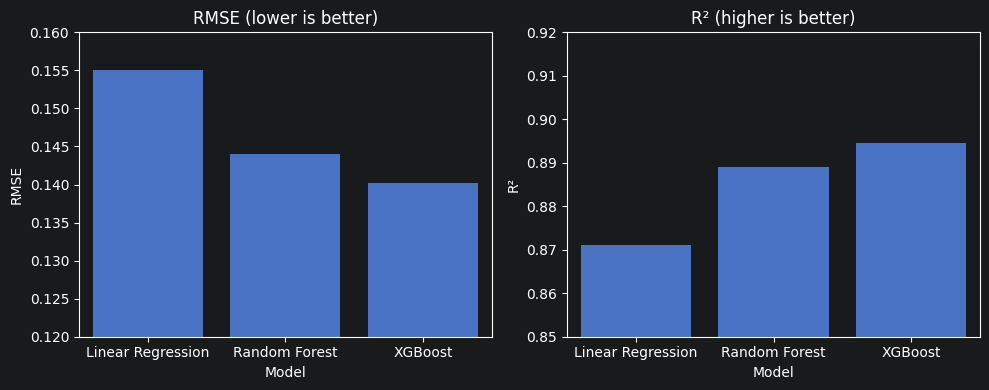

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse],
    'R²': [lr_r2, rf_r2, xgb_r2]
})

print(results.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=results, x='Model', y='RMSE', ax=ax1)
ax1.set_title('RMSE (lower is better)')
ax1.set_ylim(0.12, 0.16)

sns.barplot(data=results, x='Model', y='R²', ax=ax2)
ax2.set_title('R² (higher is better)')
ax2.set_ylim(0.85, 0.92)

plt.tight_layout()
plt.show()

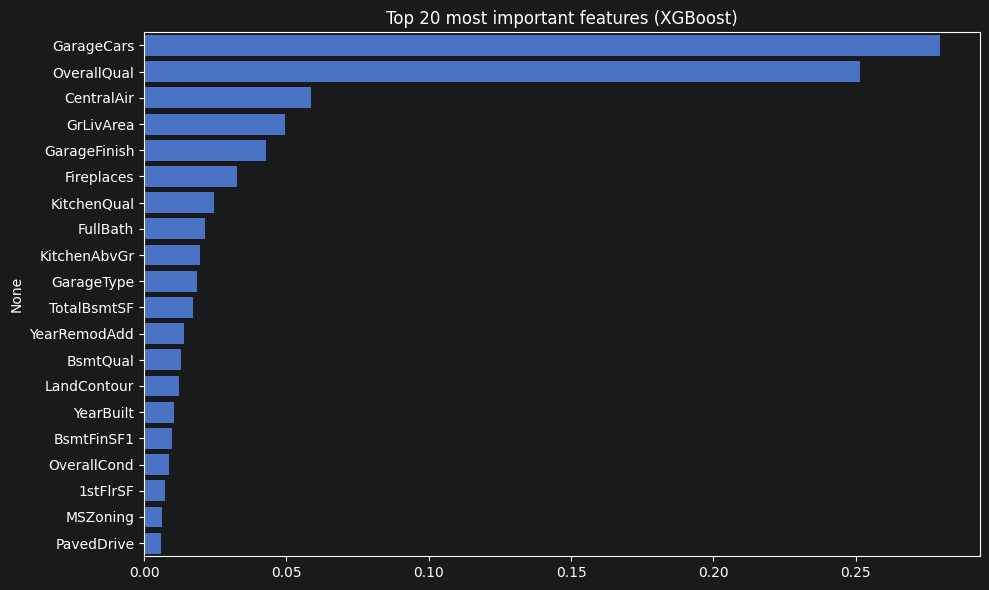

In [31]:
feat_importance = pd.Series(xgb.feature_importances_, index=X.columns)
top20 = feat_importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top20.values, y=top20.index)
plt.title('Top 20 most important features (XGBoost)')
plt.tight_layout()
plt.show()

In [30]:
test = pd.read_csv('../data/test.csv')
print(test.shape)
test.head()

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [43]:
# Drop the two extreme outliers
df = df[~((df['TotalSF'] > 6000) & (df['SalePrice'] < 200000))]

print(f'Rows after dropping outliers: {len(df)}')

# Rebuild X and y with the cleaned data
y = np.log1p(df['SalePrice'])
X = df.drop(['SalePrice', 'Id'], axis=1)

cat_cols = X.select_dtypes(include='str').columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Retrain XGBoost
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                   max_depth=4, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(f'XGBoost after outlier removal')
print(f'  RMSE: {xgb_rmse:.4f}')
print(f'  R²:   {xgb_r2:.4f}')

Rows after dropping outliers: 1457
XGBoost after outlier removal
  RMSE: 0.1321
  R²:   0.8994


In [32]:
from sklearn.model_selection import cross_val_score

def rmse_cv(model, X, y, n_folds=5):
    scores = cross_val_score(model, X, y,
                             scoring='neg_mean_squared_error',
                             cv=n_folds)
    return np.sqrt(-scores).mean()

# Test a few learning rates
for lr_rate in [0.01, 0.05, 0.1]:
    model = XGBRegressor(n_estimators=1000, learning_rate=lr_rate,
                         max_depth=4, random_state=42, verbosity=0)
    score = rmse_cv(model, X_train, y_train)
    print(f'learning_rate={lr_rate}  CV RMSE: {score:.4f}')


learning_rate=0.01  CV RMSE: 0.1313
learning_rate=0.05  CV RMSE: 0.1312
learning_rate=0.1  CV RMSE: 0.1307


In [35]:
for depth in [3, 4, 5, 6]:
    model = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                         max_depth=depth, random_state=42, verbosity=0)
    score = rmse_cv(model, X_train, y_train)
    print(f'max_depth={depth}  CV RMSE: {score:.4f}')

max_depth=3  CV RMSE: 0.1270


KeyboardInterrupt: 

In [38]:
for n in [1000]:
    model = XGBRegressor(n_estimators=n, learning_rate=0.05,
                         max_depth=3, random_state=42, verbosity=0)
    score = rmse_cv(model, X_train, y_train)
    print(f'n_estimators={n}  CV RMSE: {score:.4f}')

n_estimators=1500  CV RMSE: 0.1275


In [39]:
best_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                         max_depth=3, random_state=42, verbosity=0)
best_xgb.fit(X_train, y_train)

preds = best_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f'Tuned XGBoost')
print(f'  RMSE: {rmse:.4f}')
print(f'  R²:   {r2:.4f}')

cv_score = rmse_cv(best_xgb, X_train, y_train)
print(f'  CV RMSE: {cv_score:.4f}')

Tuned XGBoost
  RMSE: 0.1328
  R²:   0.9056
  CV RMSE: 0.1270


In [28]:
df = pd.read_csv('../data/train.csv')

# Fill missing values
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']
for col in none_cols:
    df[col] = df[col].fillna('None')
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
df = df.dropna(subset=['Electrical'])

# Features (must exist before outlier removal)
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['TotalBath'] = (df['FullBath'] + df['HalfBath'] * 0.5 +
                   df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)

# Outlier removal
df = df[~((df['TotalSF'] > 6000) & (df['SalePrice'] < 200000))]

# New features
df['TotalPorch'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                    df['3SsnPorch'] + df['ScreenPorch'])
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
df['QualityXSize'] = df['OverallQual'] * df['TotalSF']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

print('Done. Total columns:', df.shape[1])

Done. Total columns: 92


In [44]:
y = np.log1p(df['SalePrice'])
X = df.drop(['SalePrice', 'Id'], axis=1)

cat_cols = X.select_dtypes(include='str').columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                         max_depth=3, random_state=42, verbosity=0)
best_xgb.fit(X_train, y_train)

preds = best_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
cv_score = rmse_cv(best_xgb, X_train, y_train)

print(f'Tuned XGBoost + new features')
print(f'  RMSE:    {rmse:.4f}')
print(f'  R²:      {r2:.4f}')
print(f'  CV RMSE: {cv_score:.4f}')

Tuned XGBoost + new features
  RMSE:    0.1236
  R²:      0.9120
  CV RMSE: 0.1186


In [42]:
test = pd.read_csv('../data/test.csv')

# Same cleaning
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']
for col in none_cols:
    test[col] = test[col].fillna('None')
test['MasVnrArea'] = test['MasVnrArea'].fillna(0)
test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# Fill any remaining nulls with median
test = test.fillna(test.median(numeric_only=True))
test = test.fillna('None')

# Same features
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']
test['WasRemodeled'] = (test['YearRemodAdd'] != test['YearBuilt']).astype(int)
test['TotalBath'] = (test['FullBath'] + test['HalfBath'] * 0.5 +
                     test['BsmtFullBath'] + test['BsmtHalfBath'] * 0.5)
test['TotalPorch'] = (test['OpenPorchSF'] + test['EnclosedPorch'] +
                      test['3SsnPorch'] + test['ScreenPorch'])
test['HasPool'] = (test['PoolArea'] > 0).astype(int)
test['HasGarage'] = (test['GarageArea'] > 0).astype(int)
test['HasFireplace'] = (test['Fireplaces'] > 0).astype(int)
test['HasBasement'] = (test['TotalBsmtSF'] > 0).astype(int)
test['QualityXSize'] = test['OverallQual'] * test['TotalSF']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

# Encode categoricals
X_test_kaggle = test.drop(['Id'], axis=1)
cat_cols = X_test_kaggle.select_dtypes(include='str').columns
for col in cat_cols:
    le = LabelEncoder()
    X_test_kaggle[col] = le.fit_transform(X_test_kaggle[col].astype(str))

# Predict and reverse the log transform
test_preds = np.expm1(best_xgb.predict(X_test_kaggle))

# Build submission file
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_preds
})

submission.to_csv('../outputs/submission.csv', index=False)
print(submission.head())
print(f'\nSubmission saved. Shape: {submission.shape}')

     Id      SalePrice
0  1461  125691.453125
1  1462  155434.359375
2  1463  171844.625000
3  1464  184924.171875
4  1465  174034.187500

Submission saved. Shape: (1459, 2)
